# `my_beeswarm` — SHAP beeswarm без недостатков встроенного

Версия `shap.plots.beeswarm`, исправляющая три проблемы стандартной:

- **категориальные признаки**: каждое значимое значение категории выносится отдельной «псевдо-фичей»,
  так что видно направление его SHAP-вклада (порог частоты — `cat_feature_threshold`);
- **пропуски**: точки-`NaN` рисуются поверх остальных отдельным цветом и не теряются под ними;
- **покраска**: цвет считается по квантилям значений признака (палитра `coolwarm`), а не по абсолютной
  шкале — это убирает артефактные «50/50» разбиения.

Демонстрация — на LightGBM-модели и данных по недвижимости.

In [1]:
import sys
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import bokeh

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [2]:
df = pd.read_parquet('sber_data.parquet')
features = ['district_area', 'road_distance_1', 'road_distance_2',
       'year_of_construction', 'bulvar_ring_km', 'bus_station_distance',
       'cafe_count', 'fitness_center_distance', 'floor',
       'district_population', 'total_area', 'green_part',
       'green_zone_distance', 'healthcare_centers_count', 'id',
       'kitchen_area', 'kremlin_distance', 'leisure_count', 'living_area',
       'market_count', 'wall_material', 'floors_num', 'metro_minutes',
       'mkad_distance', 'rooms_num', 'office_count', 'park_distance',
       'product_type', 'public_transport_station_distance', 'sadovoe_km',
       'base_school_distance', 'sport_count', 'state', 'district_name',
       'malls_count', 'railway_station_distance', 'shadow_float_1',
       'shadow_float_2', 'shadow_float_3', 'shadow_float_4',
       'shadow_float_5', 'shadow_cat_big_1', 'shadow_cat_big_2',
       'shadow_cat_big_3', 'shadow_cat_big_4', 'shadow_cat_big_5',
       'shadow_cat_small_1', 'shadow_cat_small_2', 'shadow_cat_small_3',
       'shadow_cat_small_4', 'shadow_cat_small_5']

model = lgb.Booster(model_file='model.lgb')
shap_values = model.predict(df[features], pred_contrib=True)

'''
Учтите, что если вы считаете shap_values через LightGBM,
    shap_values - np.array of shape (N, F + 1), где последний столбец - константа = среднее предсказание для всех объектов
'''
print('features shape:', len(features), 'shap_values shape:', shap_values.shape)
df.head(3)

features shape: 51 shap_values shape: (6264, 52)


,district_area,road_distance_1,road_distance_2,year_of_construction,bulvar_ring_km,bus_station_distance,cafe_count,fitness_center_distance,floor,district_population,...,shadow_cat_big_1,shadow_cat_big_2,shadow_cat_big_3,shadow_cat_big_4,shadow_cat_big_5,shadow_cat_small_1,shadow_cat_small_2,shadow_cat_small_3,shadow_cat_small_4,shadow_cat_small_5
0,7.506452e+06,0.284868,1.478529,NaN,4.395057,6.682089,567,0.810413,14.0,19940,...,181,165,8,143,90,1,2,3,0,0
1,4.787424e+06,2.438125,2.725991,NaN,8.963023,8.571926,292,0.000000,5.0,78810,...,89,34,198,118,55,1,0,0,0,0
2,5.235177e+07,1.454206,1.511580,NaN,12.338744,16.484714,101,0.367100,4.0,78507,...,172,108,20,1,142,0,0,3,3,0


In [3]:
def my_beeswarm(shap_values, features_df, cat_feature_threshold=0.001, top_k=13, figsize=(10, 6), dots=1000):
    """
    Plots an improved beeswarm plot for SHAP values, addressing native shap.plots.beeswarm issues.
    Colors are mapped using quantiles of unique feature values to prevent artificial 50/50 color splits.

    Parameters:
    -----------
    shap_values : np.ndarray
        Array of SHAP values.
    features_df : pd.DataFrame
        DataFrame containing the original features.
    cat_feature_threshold : float
        Minimum frequency for a categorical value to be evaluated and displayed.
    top_k : int
        Number of top features to display on the plot.
    figsize : tuple
        Size of the matplotlib figure.
    dots : int
        Maximum number of points to sample for rendering.
    """
    # 1. Remove the expected_value column from LightGBM shap_values if present
    if shap_values.shape[1] == features_df.shape[1] + 1:
        shap_vals = shap_values[:, :-1]
    else:
        shap_vals = shap_values

    plot_data = []
    features = features_df.columns.tolist()

    # 2. Iterate through features to calculate SHAP statistics
    for i, col in enumerate(features):
        col_shap = shap_vals[:, i]
        col_vals = features_df[col].values

        # 3. Check if the feature is categorical
        is_categorical = pd.api.types.is_object_dtype(features_df[col]) or isinstance(features_df[col].dtype, pd.CategoricalDtype)

        if is_categorical:
            # 4. Calculate frequency of each category and apply the threshold
            value_counts = features_df[col].value_counts(normalize=True, dropna=True)
            for val, freq in value_counts.items():
                if freq >= cat_feature_threshold:
                    mask = (col_vals == val)
                    if mask.sum() > 0:
                        mean_abs_shap = np.mean(np.abs(col_shap[mask]))
                        score = mean_abs_shap * freq

                        plot_data.append({
                            'name': f"{col} = {val}",
                            'shap_array': col_shap[mask],
                            'val_array': np.ones(mask.sum()),
                            'is_nan_array': np.zeros(mask.sum(), dtype=bool),
                            'score': score,
                            'is_cat': True
                        })
        else:
            # 5. Process numerical features
            nan_mask = pd.isna(col_vals)
            mean_abs_shap = np.mean(np.abs(col_shap))

            plot_data.append({
                'name': col,
                'shap_array': col_shap,
                'val_array': col_vals,
                'is_nan_array': nan_mask,
                'score': mean_abs_shap,
                'is_cat': False
            })

    # 6. Sort features by the calculated score and keep top_k
    plot_data.sort(key=lambda x: x['score'], reverse=True)
    plot_data = plot_data[:top_k]
    plot_data.reverse()

    # 7. Initialize the plot
    fig, ax = plt.subplots(figsize=figsize)
    # Add a vertical zero-line
    ax.axvline(x=0, color='#999999', linestyle='-', linewidth=1.5, zorder=2)

    cmap = plt.get_cmap('coolwarm')
    y_labels = []

    # 8. Iterate through top features and draw points
    for y_pos, feat in enumerate(plot_data):
        y_labels.append(feat['name'])

        # Draw horizontal line for the current feature
        ax.axhline(y=y_pos, color='#e0e0e0', linestyle='-', linewidth=0.8, zorder=1)

        full_shap = feat['shap_array']
        full_val = feat['val_array']
        full_nan = feat['is_nan_array']

        # Sample points for rendering
        n_points = len(full_shap)
        if n_points > dots:
            idx = np.random.choice(n_points, size=dots, replace=False)
        else:
            idx = np.arange(n_points)

        shap_sample = full_shap[idx]
        val_sample = full_val[idx]
        nan_sample = full_nan[idx]

        valid_mask = ~nan_sample

        # 9. Plot valid (colored) points
        if valid_mask.sum() > 0:
            valid_shap = shap_sample[valid_mask]
            valid_vals = val_sample[valid_mask]

            jitter_valid = np.random.normal(0, 0.08, size=valid_mask.sum())
            jitter_valid = np.clip(jitter_valid, -0.25, 0.25)
            valid_y = y_pos + jitter_valid

            if feat['is_cat']:
                # Categories are marked with green dots
                colors = '#2ca02c'
            else:
                # Color by percentile rank of feature values
                ranks = pd.Series(valid_vals).rank(pct=True).values
                colors = cmap(ranks)

            ax.scatter(valid_shap, valid_y, color=colors, s=12, alpha=0.8, zorder=3, edgecolors='none')

        # 10. Plot NaN values with black color and very small jitter, strictly on top
        if nan_sample.sum() > 0:
            jitter_nan = np.random.normal(0, 0.015, size=nan_sample.sum())
            jitter_nan = np.clip(jitter_nan, -0.05, 0.05)
            nan_y = y_pos + jitter_nan

            ax.scatter(shap_sample[nan_sample], nan_y, color='black', s=12, alpha=1.0,
                       zorder=10, edgecolors='none')

    # 11. Format axes and the colorbar
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)
    ax.set_ylabel("Features", fontsize=10)
    ax.set_xlabel("Contribution", fontsize=10)

    sm = ScalarMappable(cmap=cmap, norm=Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, aspect=40)
    cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar.set_ticklabels(['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'])

    plt.tight_layout()
    plt.show()

### Демонстрация

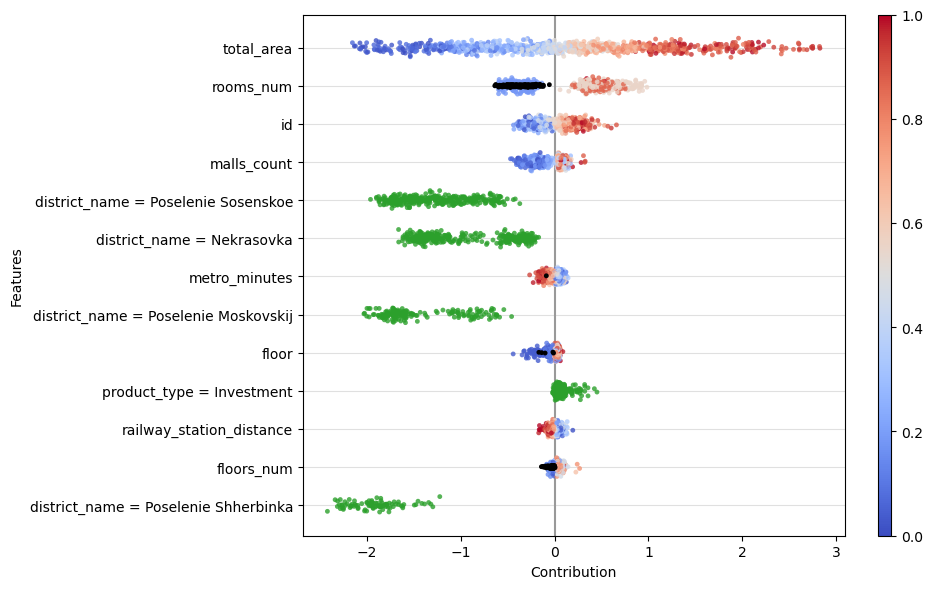

In [4]:
my_beeswarm(
    shap_values=shap_values,
    features_df=df[features],
    cat_feature_threshold=0.001,
    top_k=13,
    figsize=(10, 6),
    dots=1000
)

<!-- скриншот вывода beeswarm можно добавить сюда после запуска -->